In [19]:
import sys
sys.path.insert(0, '../Week-5-6-7-8')

import json
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR, NuSVR
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from tqdm import tqdm

from helpers.modeling import identify_column_types, create_preprocessor, evaluate_model
from uncertainty import conformal_quantile, build_intervals, calibration_table

with open('../Week-5-6-7-8/results.json', 'r') as f:
    results = json.load(f)

df = pd.read_csv("../Datasets/processed/UHPC_dataset/semantic_recoding_features_50_with_publications.csv")

In [20]:
target_col = 'cs_28d'
pub_col    = 'paper_reference'
threshold  = 5
alpha      = 0.90

X = df.drop(columns=[target_col, pub_col])
y = df[target_col]

# Preprocessor template — cloned fresh for every pipeline fit inside the loop
numerical_cols, one_hot_cols, k_fold_cols = identify_column_types(X)
preprocessor_template = create_preprocessor(numerical_cols, one_hot_cols, k_fold_cols,
                                             handle_unknown='ignore')

model_configs = [
    ('knn',   KNeighborsRegressor, 'knn'),
    ('svr',   SVR,                 'svr'),
    ('nusvr', NuSVR,               'nusvr'),
]

selected_pubs = [
    pub for pub, grp in df.groupby(pub_col) if len(grp) >= threshold
]
print(f"Publications with >= {threshold} rows: {len(selected_pubs)} / {df[pub_col].nunique()}")

Publications with >= 5 rows: 123 / 165


In [21]:
all_intervals = []

for pub_id in tqdm(selected_pubs):
    test_mask = df[pub_col] == pub_id
    X_te = X[test_mask]
    y_te = y[test_mask]

    X_tr_all = X[~test_mask]
    y_tr_all = y[~test_mask]

    # Hold out 15 % of training as calibration set for conformal interval
    X_tr_fit, X_cal, y_tr_fit, y_cal = train_test_split(
        X_tr_all, y_tr_all, test_size=0.15, random_state=42
    )

    for model_name, model_cls, param_key in model_configs:
        params = results["best_params"]["recoded_50"][param_key]
        pipeline = Pipeline([
            ('preprocessor', clone(preprocessor_template)),
            ('model',        model_cls()),
        ])
        pipeline.set_params(**params)
        pipeline.fit(X_tr_fit, y_tr_fit)

        q = conformal_quantile(pipeline, X_cal, y_cal, alpha)
        row_df = build_intervals(
            pipeline, X_te, y_te,
            pd.Series([pub_id] * len(X_te), name='publication'),
            q, X_tr_fit
        )
        row_df['model'] = model_name
        all_intervals.append(row_df)

logo_intervals = pd.concat(all_intervals, ignore_index=True)
print(f"Total predicted rows: {len(logo_intervals)}")
logo_intervals.head()

100%|██████████| 123/123 [08:35<00:00,  4.19s/it]

Total predicted rows: 5841


,publication,prediction,true,lower,upper,residual,mean_distance,model
0,Ref-1-data,129.921430,135.0,105.074827,154.768033,5.078570,6.166403,knn
1,Ref-1-data,129.191685,132.0,104.345082,154.038288,2.808315,6.258214,knn
2,Ref-1-data,115.766311,122.5,90.919708,140.612914,6.733689,6.274149,knn
3,Ref-1-data,115.933780,116.0,91.087177,140.780383,0.066220,4.414534,knn
4,Ref-1-data,126.834508,134.0,101.987905,151.681111,7.165492,7.581117,knn


In [22]:
# Pooled metrics per model across all LOGO folds
for model_name in ['knn', 'svr', 'nusvr']:
    df_m = logo_intervals[logo_intervals['model'] == model_name]
    rmse = np.sqrt((df_m['residual'] ** 2).mean())
    mae  = df_m['residual'].mean()
    cov  = ((df_m['true'] >= df_m['lower']) & (df_m['true'] <= df_m['upper'])).mean()
    w    = (df_m['upper'] - df_m['lower']).mean()
    print(f"{model_name.upper():6s} | RMSE={rmse:.2f}  MAE={mae:.2f}  Coverage={cov:.2%}  Avg Width={w:.2f}")

KNN    | RMSE=25.54  MAE=19.01  Coverage=75.14%  Avg Width=53.34
SVR    | RMSE=29.28  MAE=22.22  Coverage=59.94%  Avg Width=44.03
NUSVR  | RMSE=28.36  MAE=21.37  Coverage=60.71%  Avg Width=43.68


In [23]:
# Per-publication calibration table — KNN
cal_logo_knn = calibration_table(
    logo_intervals[logo_intervals['model'] == 'knn']
)
cal_logo_knn

,publication,n_rows,mean_true,mean_prediction,coverage,interval_width,mean_residual,mean_distance
0,Ref-1-data,16,126.250000,127.004800,1.000000,49.693206,7.801250,6.691025
1,Ref-10-Research,7,147.471429,112.640546,0.428571,63.822736,36.943229,7.544733
2,Ref-100-Research,8,115.037500,153.163263,0.125000,56.826300,38.125763,7.343179
3,Ref-101-Research,28,172.892857,183.434422,0.714286,49.925211,18.210122,2.275986
4,Ref-102-Research,16,169.500000,187.261785,0.687500,52.644073,19.940069,6.432877
...,...,...,...,...,...,...,...,...
118,Ref-93-Research,10,131.300000,121.724361,0.700000,60.625548,22.341580,8.690708
119,Ref-94-Research,5,166.000000,156.542638,0.800000,51.095920,11.353961,8.211974
120,Ref-96-Research,8,142.750000,145.958242,1.000000,60.051058,4.759261,5.672063
121,Ref-98-Research,16,140.562500,134.733449,1.000000,52.337336,11.108013,7.930211


In [24]:
# Per-publication calibration table — SVR
cal_logo_svr = calibration_table(
    logo_intervals[logo_intervals['model'] == 'svr']
)
cal_logo_svr

,publication,n_rows,mean_true,mean_prediction,coverage,interval_width,mean_residual,mean_distance
0,Ref-1-data,16,126.250000,148.182647,0.437500,39.748207,21.932647,2.754691
1,Ref-10-Research,7,147.471429,128.320669,0.714286,54.018516,19.150760,3.047616
2,Ref-100-Research,8,115.037500,132.370697,0.750000,46.484428,18.453853,2.821649
3,Ref-101-Research,28,172.892857,178.205145,0.892857,44.606367,9.787097,1.254087
4,Ref-102-Research,16,169.500000,187.096761,0.500000,41.849005,19.550758,2.603638
...,...,...,...,...,...,...,...,...
118,Ref-93-Research,10,131.300000,142.810692,0.700000,39.972110,18.369153,3.785300
119,Ref-94-Research,5,166.000000,153.024508,0.800000,41.298418,12.975492,3.141061
120,Ref-96-Research,8,142.750000,144.279297,1.000000,45.699115,5.336723,3.033695
121,Ref-98-Research,16,140.562500,131.449237,1.000000,42.064557,10.272951,4.124693


In [25]:
# Per-publication calibration table — NuSVR
cal_logo_nusvr = calibration_table(
    logo_intervals[logo_intervals['model'] == 'nusvr']
)
cal_logo_nusvr

,publication,n_rows,mean_true,mean_prediction,coverage,interval_width,mean_residual,mean_distance
0,Ref-1-data,16,126.250000,148.553610,0.437500,42.105907,22.303610,2.753259
1,Ref-10-Research,7,147.471429,125.219803,0.714286,54.590136,22.251626,3.047574
2,Ref-100-Research,8,115.037500,123.980528,0.750000,44.840550,15.353455,2.823738
3,Ref-101-Research,28,172.892857,177.956481,0.892857,45.296852,9.813077,1.254147
4,Ref-102-Research,16,169.500000,184.286695,0.625000,43.195062,19.045277,2.603705
...,...,...,...,...,...,...,...,...
118,Ref-93-Research,10,131.300000,155.670367,0.400000,41.779306,24.370367,3.751227
119,Ref-94-Research,5,166.000000,152.480691,0.800000,41.938579,13.519309,3.144374
120,Ref-96-Research,8,142.750000,143.664804,1.000000,44.179134,5.383307,3.033117
121,Ref-98-Research,16,140.562500,134.430894,1.000000,44.050171,7.022220,4.124693


In [26]:
poor_coverage_threshold = 0.90

poor_coverage_logo = pd.concat([
    cal_logo_knn.assign(model='knn'),
    cal_logo_svr.assign(model='svr'),
    cal_logo_nusvr.assign(model='nusvr'),
])
poor_coverage_logo = (
    poor_coverage_logo[poor_coverage_logo['coverage'] < poor_coverage_threshold]
    .sort_values('coverage')
    [['model', 'publication', 'n_rows', 'coverage', 'interval_width', 'mean_residual', 'mean_distance']]
    .reset_index(drop=True)
)

print(f"Publications below {poor_coverage_threshold:.0%} coverage: {poor_coverage_logo['publication'].nunique()} unique, {len(poor_coverage_logo)} model-publication pairs")
poor_coverage_logo

Publications below 90% coverage: 101 unique, 257 model-publication pairs


,model,publication,n_rows,coverage,interval_width,mean_residual,mean_distance
0,knn,Ref-145-Research,7,0.000000,56.087760,61.776801,8.402210
1,knn,Ref-163-Research,5,0.000000,44.794882,61.961610,6.599180
2,nusvr,Ref-53-Research,8,0.000000,40.957998,33.150573,2.256362
3,nusvr,Ref-50-Research,21,0.000000,43.637782,49.351000,2.843768
4,knn,Ref-88-Research,8,0.000000,59.042265,45.851030,5.966096
...,...,...,...,...,...,...,...
252,knn,Ref-141-Research,73,0.890411,52.327929,15.133534,12.393526
253,nusvr,Ref-101-Research,28,0.892857,45.296852,9.813077,1.254147
254,svr,Ref-101-Research,28,0.892857,44.606367,9.787097,1.254087
255,svr,Ref-63-Research,19,0.894737,47.645307,15.612656,2.697273


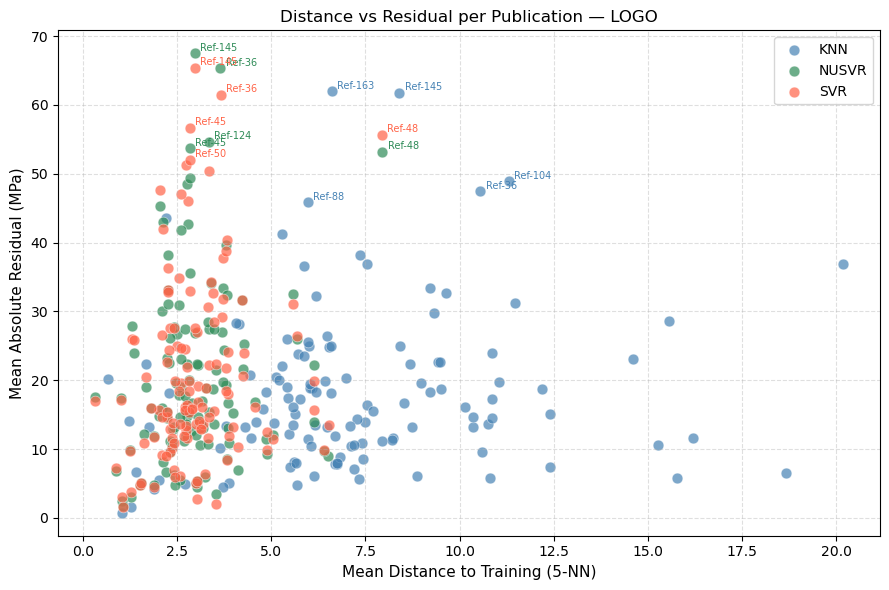

In [27]:
import matplotlib.pyplot as plt

all_cal_logo = pd.concat([
    cal_logo_knn.assign(model='knn'),
    cal_logo_svr.assign(model='svr'),
    cal_logo_nusvr.assign(model='nusvr'),
], ignore_index=True)

colors = {'knn': 'steelblue', 'svr': 'tomato', 'nusvr': 'seagreen'}

fig, ax = plt.subplots(figsize=(9, 6))

for model_name, grp in all_cal_logo.groupby('model'):
    ax.scatter(grp['mean_distance'], grp['mean_residual'],
               label=model_name.upper(), color=colors[model_name],
               alpha=0.7, edgecolors='white', linewidths=0.4, s=60)

for model_name, grp in all_cal_logo.groupby('model'):
    for _, row in grp.nlargest(5, 'mean_residual').iterrows():
        ax.annotate(row['publication'].replace('-Research', '').replace('-data', ''),
                    xy=(row['mean_distance'], row['mean_residual']),
                    fontsize=7, color=colors[model_name],
                    xytext=(4, 2), textcoords='offset points')

ax.set_xlabel('Mean Distance to Training (5-NN)', fontsize=11)
ax.set_ylabel('Mean Absolute Residual (MPa)', fontsize=11)
ax.set_title('Distance vs Residual per Publication — LOGO', fontsize=12)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()